# DoriaNET Damage Classification Project — Group 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin

**Course:** Artificial Intelligence, Appalachian State University

**GitHub:** https://github.com/zachshotwell/AI-FinalProject-GroupSCR

**Dataset:** DoriaNET, an annotated subset of post-Hurricane-Dorian UAV footage from Marsh Harbor, Bahamas (Cheng, Behzadan, & Noshadravan 2021), containing 271 video frames, 1,458 (frame, building) instances across 147 distinct physical buildings, and per-instance pixel masks plus FEMA HAZUS damage state labels (0–5).

**Task:** Classify each cropped building patch into one of six FEMA HAZUS damage states, where 0 = no damage and 5 = under construction or destroyed — a 6-class ordinal image classification problem.

**Approach:** After parsing the dataset's JSON annotations and extracting per-building patches via the provided masks, we build a building-stratified train/val/test split and benchmark three classifiers: an MLP baseline, a from-scratch CNN, and a transfer-learning model based on MobileNetV2 with two-step fine-tuning. Models are evaluated with overall and ±1 accuracy, F1 macro, confusion matrices, and difficulty-stratified accuracy following the paired paper.

## Setup

In [1]:
!git clone https://github.com/zachshotwell/AI-FinalProject-GroupSCR
%cd AI-FinalProject-GroupSCR
%cd DoriaNETProject
!ls

Cloning into 'AI-FinalProject-GroupSCR'...
remote: Enumerating objects: 2232, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 2232 (delta 91), reused 5 (delta 2), pack-reused 2071 (from 2)
Receiving objects: 100% (2232/2232), 68.19 MiB | 19.92 MiB/s, done.
Resolving deltas: 100% (1750/1750), done.
Updating files: 100% (2061/2061), done.
/content/AI-FinalProject-GroupSCR
/content/AI-FinalProject-GroupSCR/DoriaNETProject
 data
 DoriaNET.ipynb
'DoriaNET report.pdf'
'main paper. Deep learning for post-hurricane aerial damage assessmentof buildings.pdf'
 README.md


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split

tf.random.set_seed(42)
np.random.seed(42)

print(f"TF version: {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")

DATA_ROOT = Path("data")
FRAME_DIR = DATA_ROOT / "FRAME"
MASK_DIR  = DATA_ROOT / "MASK"
JSON_DIR  = DATA_ROOT / "JSON"

TF version: 2.20.0
GPU available: True


## Data Reconnaissance

Before building the loader, we inspect file counts and one sample of each file type
across the FRAME, MASK, and JSON folders to confirm the on-disk layout matches the
schema described in the dataset paper.

This check is used to verify:
- file counts in each folder
- naming convention and per-folder file extensions
- frame and mask image dimensions
- rough alignment with the paper's stated 271-frame, 1,458-mask, 271-JSON layout

This section is exploratory only; final parsing and integrity checks are done in the
data preparation and EDA sections.

In [3]:
frame_files = sorted(FRAME_DIR.glob("*.jpg"))
mask_files  = sorted(MASK_DIR.glob("*.jpg"))
json_files  = sorted(JSON_DIR.glob("*.json"))

print(f"FRAME : {len(frame_files):>5} files")
print(f"MASK  : {len(mask_files):>5} files")
print(f"JSON  : {len(json_files):>5} files")

# Resolution check: paper specifies 1280×720
print(f"\nframe[0] shape: {plt.imread(frame_files[0]).shape}")
print(f"mask[0]  shape: {plt.imread(mask_files[0]).shape}")

FRAME :   271 files
MASK  :  1458 files
JSON  :   271 files

frame[0] shape: (720, 1280, 3)
mask[0]  shape: (720, 1280, 3)


## Data Preparation

This section parses the 271 per-frame JSON annotation files into a single tidy
table, with one row per (frame, building) instance. The DoriaNET schema stores
each building as a positional 7-element list rather than a named-field dict
(building ID, "lat, lon" string, mask filename, damage state, stories,
annotation effort, and one unused field). The parser:

- splits the `"lat, lon"` string into two float columns
- strips the `FRAME/` prefix from `Frame_Name` so it joins cleanly with on-disk filenames
- ignores the seventh field (NaN in all 1,458 records)

The resulting dataframe is the working table for the rest of the notebook: every
downstream cell selects rows from it by index.

In [4]:
def parse_frame_json(path):
    with open(path) as f:
        d = json.load(f)
    rows = []
    for b in d["Buildings"]:  # 7-element list per the DoriaNET schema
        lat, lon = (float(x) for x in b[1].split(","))
        rows.append({
            "frame_name":  Path(d["Frame_Name"]).name,
            "building_id": b[0],
            "lat":         lat,
            "lon":         lon,
            "mask_name":   b[2],
            "damage":      b[3],
            "stories":     b[4],
            "effort":      b[5],
        })
    return rows

records = [r for p in json_files for r in parse_frame_json(p)]
df = pd.DataFrame(records)

print(f"Building instances: {len(df)}")
print(f"Distinct frames   : {df['frame_name'].nunique()}")
print(f"Distinct buildings: {df['building_id'].nunique()}")
df.head()

Building instances: 1458
Distinct frames   : 271
Distinct buildings: 147


,frame_name,building_id,lat,lon,mask_name,damage,stories,effort
0,1_0373.jpg,B004,26.55438,-77.09680,1_0373_B0XX_0_Level1.jpg,1,1,1
1,1_0379.jpg,B001,26.55511,-77.10044,1_0379_B0XX_0_Level0.jpg,0,1,1
2,1_0379.jpg,B002,26.55516,-77.09986,1_0379_B0XX_0_Level2.jpg,2,1,1
3,1_0379.jpg,B003,26.55452,-77.09913,1_0379_B0XX_0_Level3.jpg,3,1,1
4,1_0405.jpg,B001,26.55511,-77.10044,1_0405_B0XX_0_Level0.jpg,0,1,1


## Exploratory Data Analysis

This section visualizes the dataset's class structure and confirms the mapping
between JSON annotations and on-disk files. The goals are to:

- show the distribution of damage states, annotation difficulty, and building stories
- summarize how many frames each building appears in (mean ≈ 10, max = 39)
- cross-tabulate damage state against annotation difficulty
- verify that every JSON-referenced frame and mask exists on disk and that masks
  share the parent frame's dimensions
- visualize one frame with all of its building masks colored by damage state

The damage distribution and integrity checks confirm we have the full Dataset 1
from Cheng et al. (2021), with no missing files or orphan masks.

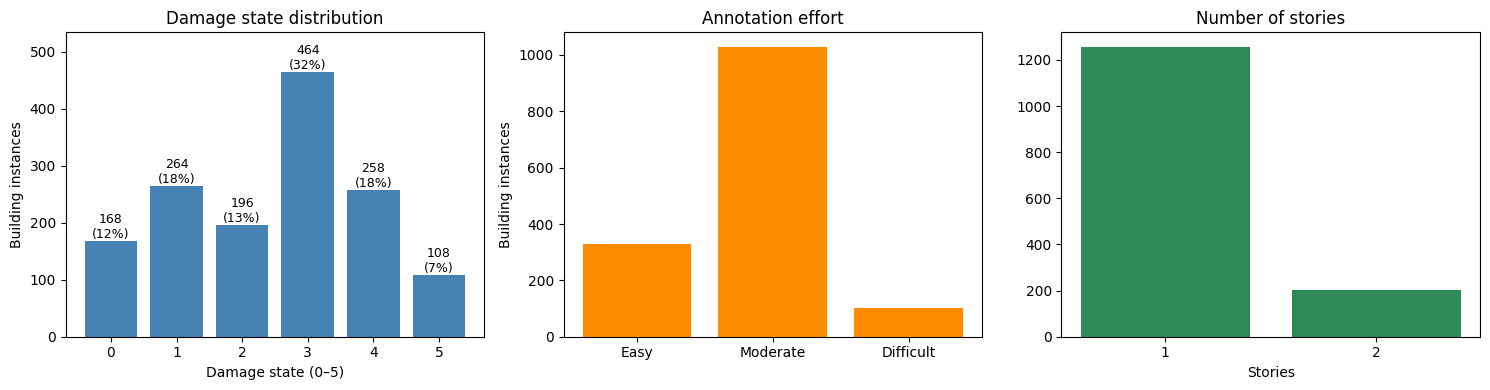

Frame appearances per building:
count    147.0
mean       9.9
std        7.9
min        1.0
25%        4.0
50%        8.0
75%       13.0
max       39.0
dtype: float64

Damage × Effort cross-tab:
effort    0     1    2   All
damage                      
0        26   126   16   168
1        65   193    6   264
2        42   134   20   196
3       133   300   31   464
4        50   195   13   258
5        12    81   15   108
All     328  1029  101  1458

Missing frames (referenced by JSON, not on disk): 0
Missing masks  (referenced by JSON, not on disk): 0
Orphan frames  (on disk, not referenced)        : 0
Orphan masks   (on disk, not referenced)        : 0


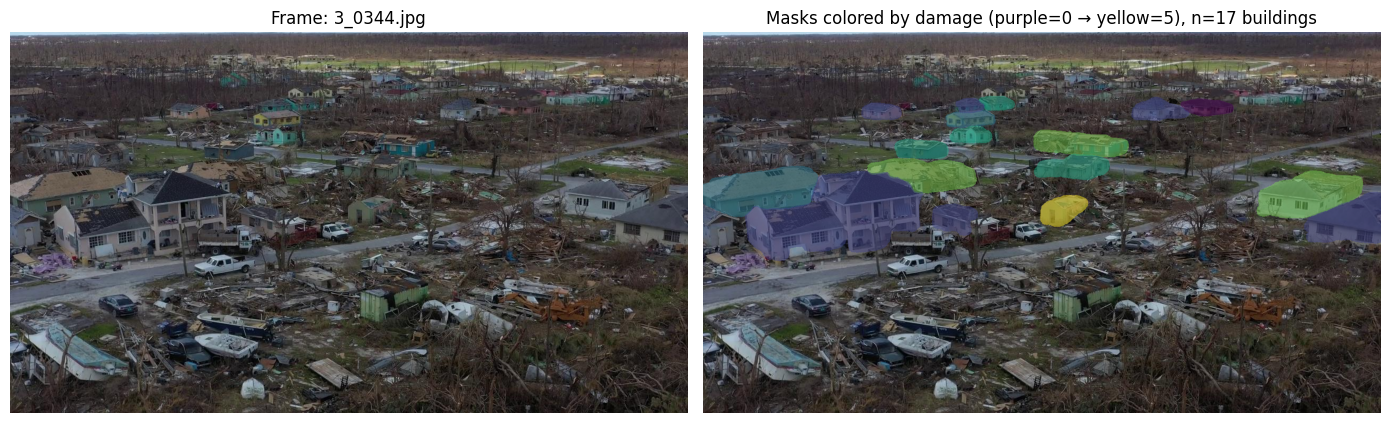

In [5]:
# 1) Distributions of damage / effort / stories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dmg = df["damage"].value_counts().sort_index()
axes[0].bar(dmg.index.astype(str), dmg.values, color="steelblue")
axes[0].set_title("Damage state distribution")
axes[0].set_xlabel("Damage state (0–5)")
axes[0].set_ylabel("Building instances")
axes[0].set_ylim(0, dmg.max() * 1.15)
for i, v in enumerate(dmg.values):
    axes[0].text(i, v + 5, f"{v}\n({100*v/len(df):.0f}%)", ha="center", fontsize=9)

eff = df["effort"].value_counts().sort_index()
axes[1].bar(["Easy", "Moderate", "Difficult"], eff.values, color="darkorange")
axes[1].set_title("Annotation effort")
axes[1].set_ylabel("Building instances")

stry = df["stories"].value_counts().sort_index()
axes[2].bar(stry.index.astype(str), stry.values, color="seagreen")
axes[2].set_title("Number of stories")
axes[2].set_xlabel("Stories")

plt.tight_layout()
plt.show()

# 2) Building structure and difficulty cross-tab
print("Frame appearances per building:")
print(df.groupby("building_id").size().describe().round(1))

print("\nDamage × Effort cross-tab:")
print(pd.crosstab(df["damage"], df["effort"], margins=True))

# 3) FRAME / MASK correspondence between JSON references and files on disk
frame_set_json = set(df["frame_name"])
mask_set_json  = set(df["mask_name"])
frame_set_disk = {p.name for p in frame_files}
mask_set_disk  = {p.name for p in mask_files}

print(f"\nMissing frames (referenced by JSON, not on disk): {len(frame_set_json - frame_set_disk)}")
print(f"Missing masks  (referenced by JSON, not on disk): {len(mask_set_json - mask_set_disk)}")
print(f"Orphan frames  (on disk, not referenced)        : {len(frame_set_disk - frame_set_json)}")
print(f"Orphan masks   (on disk, not referenced)        : {len(mask_set_disk - mask_set_json)}")

# 4) Sample frame: masks colored by damage state
sample_frame = df["frame_name"].value_counts().idxmax()
sample_rows = df[df["frame_name"] == sample_frame]

base = plt.imread(FRAME_DIR / sample_frame).astype(float) / 255.0
overlay = base.copy()
for _, row in sample_rows.iterrows():
    m = plt.imread(MASK_DIR / row["mask_name"])
    if m.ndim == 3:
        m = m.mean(axis=-1)
    color = np.array(plt.cm.viridis(row["damage"] / 5)[:3])
    overlay[m > 127] = 0.5 * overlay[m > 127] + 0.5 * color

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(base)
axes[0].set_title(f"Frame: {sample_frame}")
axes[0].axis("off")
axes[1].imshow(overlay)
axes[1].set_title(f"Masks colored by damage (purple=0 → yellow=5), n={len(sample_rows)} buildings")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Building-Stratified Train/Validation/Test Split

To prevent identity leakage, the 147 distinct physical buildings are split
between train, validation, and test rather than the 1,458 (frame, building)
instances. A row-level shuffle would place the same physical building in all
three splits at slightly different angles, letting the model memorize
building-specific features rather than learn damage patterns.

The split rule:

- 60% of buildings to train, 20% to validation, 20% to test
- stratified by each building's modal damage state, so all three splits see
  roughly the population class distribution
- random seed selected from a 50-seed search to maximize the smallest
  per-(split, class) cell count, ensuring rare classes (0, 5) are adequately
  represented in val and test

This split is more rigorous than the row-level split used in the paired paper.
We expect to underperform the paper's reported accuracy as a direct result of
removing the within-building leakage their split contains.

In [6]:
# One row per building, with its modal damage state for stratification
building_summary = (df.groupby("building_id")
                      .agg(modal_damage=("damage", lambda s: s.mode().iloc[0]))
                      .reset_index())

# 60/20/20 building-level split, stratified by modal damage class.
# seed=8 was chosen via search over 50 seeds to maximize the smallest (val/test, class) cell.
train_bld, temp_bld = train_test_split(
    building_summary, test_size=0.40,
    stratify=building_summary["modal_damage"], random_state=8)
val_bld, test_bld = train_test_split(
    temp_bld, test_size=0.50,
    stratify=temp_bld["modal_damage"], random_state=8)

train_ids = set(train_bld["building_id"])
val_ids   = set(val_bld["building_id"])
test_ids  = set(test_bld["building_id"])

df["split"] = df["building_id"].map(
    lambda b: "train" if b in train_ids else ("val" if b in val_ids else "test"))

print("Buildings and instances per split:")
for s in ["train", "val", "test"]:
    n_b = df.loc[df["split"] == s, "building_id"].nunique()
    n_i = (df["split"] == s).sum()
    print(f"  {s:5s}: {n_b:3d} buildings, {n_i:4d} instances ({100*n_i/len(df):.1f}%)")

print("\nDamage distribution per split (row-normalized):")
print(pd.crosstab(df["split"], df["damage"], normalize="index").round(3))

Buildings and instances per split:
  train:  88 buildings,  794 instances (54.5%)
  val  :  29 buildings,  315 instances (21.6%)
  test :  30 buildings,  349 instances (23.9%)

Damage distribution per split (row-normalized):
damage      0      1      2      3      4      5
split                                           
test    0.166  0.195  0.163  0.223  0.186  0.066
train   0.105  0.199  0.144  0.312  0.191  0.049
val     0.086  0.121  0.079  0.438  0.130  0.146


## Patch Extraction and Dataset Construction

This section converts the per-instance frame/mask pairs into fixed-size image
patches suitable for CNN input, and wraps them in `tf.data` pipelines for
training, validation, and testing.

For each (frame, building) instance:

1. Load the frame and its full-frame binary mask (`mean(channels) > 127`)
2. Crop the frame to the mask's bounding box
3. Pad the crop to square (avoids aspect-ratio distortion on resize)
4. Resize to 224×224 with bilinear interpolation, store as `uint8`

All 1,458 patches fit in a single `(1458, 224, 224, 3)` array (~219 MB),
which is held in memory rather than re-decoded each epoch.

Training-time augmentation follows Cheng et al. (2021) §3.1.2: horizontal flip,
±15° rotation, ±20% zoom. Augmentation is applied at the dataset level via
`.map()` rather than as model layers, so all three architectures share the
same training pipeline.

  processed 50/271 frames
  processed 100/271 frames
  processed 150/271 frames
  processed 200/271 frames
  processed 250/271 frames
  processed 271/271 frames

Patches: (1458, 224, 224, 3), uint8, 219 MB


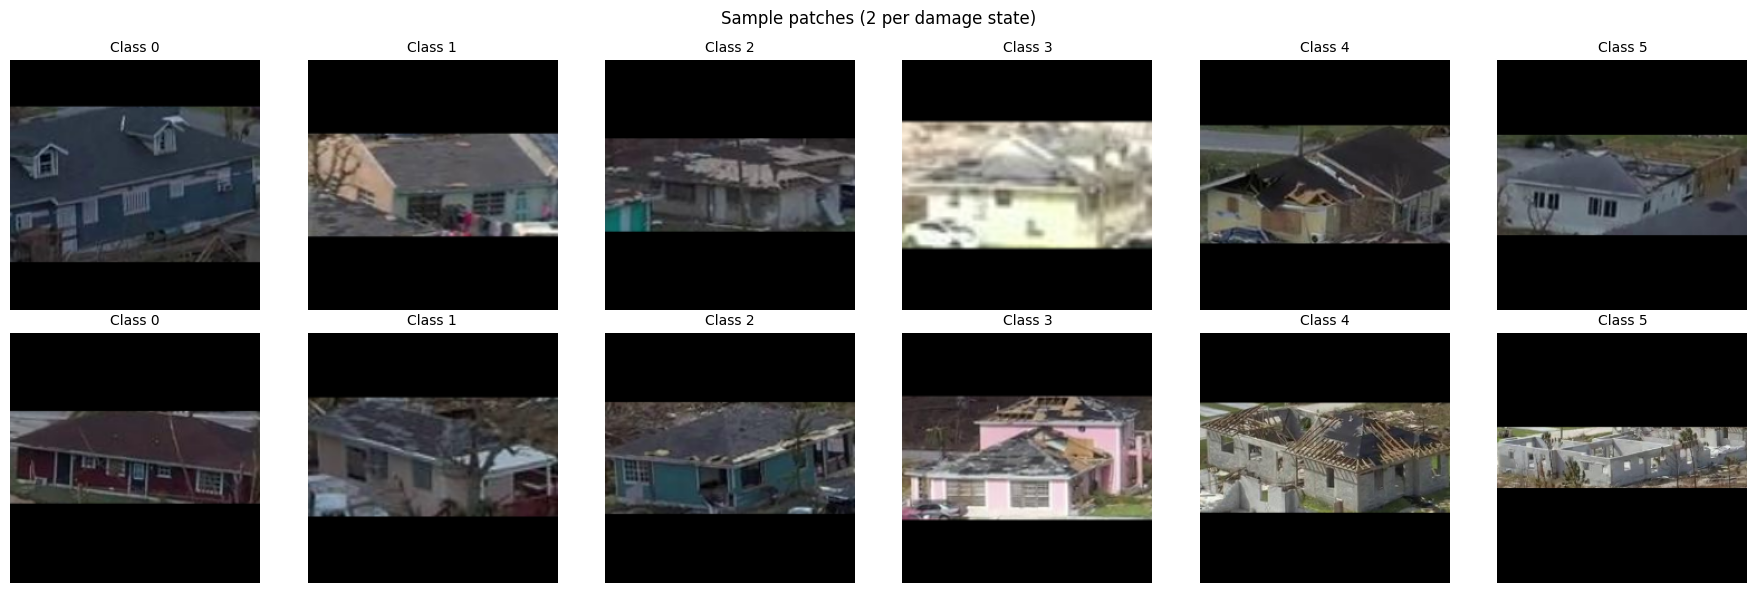

In [7]:
def extract_patch(frame, mask_bool, size=224):
    rows = np.where(np.any(mask_bool, axis=1))[0]
    cols = np.where(np.any(mask_bool, axis=0))[0]
    crop = frame[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]
    h, w = crop.shape[:2]
    side = max(h, w)
    out = np.zeros((side, side, 3), dtype=np.uint8)
    out[(side - h) // 2:(side - h) // 2 + h,
        (side - w) // 2:(side - w) // 2 + w] = crop
    return tf.image.resize(out, (size, size), method="bilinear").numpy().astype(np.uint8)


# Extract one patch per (frame, building) instance
patches = np.zeros((len(df), 224, 224, 3), dtype=np.uint8)
n_frames = df["frame_name"].nunique()
for i, (fname, group) in enumerate(df.groupby("frame_name")):
    frame = plt.imread(FRAME_DIR / fname)
    for idx, row in group.iterrows():
        mask = plt.imread(MASK_DIR / row["mask_name"])
        mb = mask.mean(axis=-1) > 127 if mask.ndim == 3 else mask > 127
        patches[idx] = extract_patch(frame, mb)
    if (i + 1) % 50 == 0 or i + 1 == n_frames:
        print(f"  processed {i+1}/{n_frames} frames")

print(f"\nPatches: {patches.shape}, {patches.dtype}, {patches.nbytes / 1e6:.0f} MB")

# Sample patches (2 per damage state) — sanity check on extraction
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for cls in range(6):
    for r, ix in enumerate(df[df["damage"] == cls].sample(2, random_state=42).index):
        axes[r, cls].imshow(patches[ix])
        axes[r, cls].set_title(f"Class {cls}", fontsize=10)
        axes[r, cls].axis("off")
plt.suptitle("Sample patches (2 per damage state)")
plt.tight_layout()
plt.show()

# Per-split feature/target arrays
train_idx = df.index[df["split"] == "train"].to_numpy()
val_idx   = df.index[df["split"] == "val"].to_numpy()
test_idx  = df.index[df["split"] == "test"].to_numpy()

X_train, y_train = patches[train_idx], df.loc[train_idx, "damage"].to_numpy()
X_val,   y_val   = patches[val_idx],   df.loc[val_idx,   "damage"].to_numpy()
X_test,  y_test  = patches[test_idx],  df.loc[test_idx,  "damage"].to_numpy()

# Augmentation pipeline (training only). Geometry follows Cheng et al. (2021) §3.1.2:
# horizontal flip, ±15° rotation, ±20% scale.
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.04, seed=42),
    tf.keras.layers.RandomZoom(0.2, seed=42),
], name="augment")

# tf.data pipelines
BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=42, reshuffle_each_iteration=True)
            .batch(BATCH)
            .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds  = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH).prefetch(AUTOTUNE)

## MLP, Standard CNN, MobileNetV2, and MobileNetV1

Four architectures are trained, in increasing order of architectural prior and external information:

- **MLP**: `AvgPool(4) → Flatten → Dense(256) → Dense(128) → Dense(6)` — fully-connected baseline applied to raw pixels with no spatial inductive bias.
- **Standard CNN**: three `Conv2D + MaxPool` blocks (32, 64, 128 filters) → `GlobalAveragePooling2D → Dense(64) → Dense(6)` — the canonical textbook vision architecture, trained from scratch.
- **MobileNetV2 with two-step transfer learning** — pretrained ImageNet backbone with custom head: `GlobalAveragePooling2D → Dropout(0.5) → Dense(6)`. Step 1 trains the head only at `lr=1e-3` for 25 epochs. Step 2 unfreezes the backbone and continues at `lr=1e-4`, gently adapting ImageNet features to UAV imagery. This recipe is from Cheng et al. (2021) §3.1.2.
- **MobileNetV1 with two-step transfer learning** — same recipe and head as MobileNetV2, but with the V1 backbone (the architecture Cheng et al. (2021) actually use). MobileNetV2 was adopted initially as the more recent variant of the MobileNet family; the M3 hyperparameter sweep flagged V1 as substantially better in our setting, motivating its inclusion as a primary model.

Training configuration:
- Loss: sparse categorical cross-entropy
- Optimizer: Adam, `lr=1e-3` for from-scratch training, `lr=1e-4` for MobileNet fine-tuning
- Callbacks: `EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)` and `ReduceLROnPlateau(factor=0.5, patience=5)`
- `clear_session()` and `set_seed(42)` before each model build, per Géron NB1 convention

We initially tried EMD² (squared earth-mover's distance) loss per the paper's recommendation but observed that the from-scratch models collapsed to majority-class prediction and that MobileNet underperformed cross-entropy in our setup. Cross-entropy across all four models is therefore both simpler and empirically better for our small-data regime; the discussion lives in the project documentation.

In [8]:
def make_callbacks(patience=10):
    return [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5),
    ]


# --- MLP ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
mlp = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.AveragePooling2D(pool_size=4),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="mlp")
mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"MLP ({mlp.count_params():,} params)")
hist_mlp = mlp.fit(train_ds, validation_data=val_ds, epochs=100,
                   callbacks=make_callbacks(), verbose=2)


# --- Standard CNN ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
cnn = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    tf.keras.layers.Rescaling(1/255),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax"),
], name="cnn")
cnn.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
            loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print(f"\nCNN ({cnn.count_params():,} params)")
hist_cnn = cnn.fit(train_ds, validation_data=val_ds, epochs=100,
                   callbacks=make_callbacks(patience=5), verbose=2)


# --- MobileNetV2 with two-step transfer learning per Cheng et al. (2021) §3.1.2 ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone = tf.keras.applications.MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV2 expects [-1, 1]
x = backbone(x, training=False)                              # keep BN in inference mode for step 1
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv2 = tf.keras.Model(inputs, outputs, name="mobilenetv2")

print(f"\nMobileNetV2 ({mbv2.count_params():,} params, step 1: head only, lr=1e-3)")
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s1 = mbv2.fit(train_ds, validation_data=val_ds, epochs=25,
                         callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV2 step 2: full fine-tune, lr=1e-4")
backbone.trainable = True
mbv2.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv2_s2 = mbv2.fit(train_ds, validation_data=val_ds, epochs=100,
                         initial_epoch=len(hist_mbv2_s1.history["loss"]),
                         callbacks=make_callbacks(), verbose=2)

# Concatenated history for plotting (preserves the step1/step2 boundary)
hist_mbv2 = {k: hist_mbv2_s1.history[k] + hist_mbv2_s2.history[k]
             for k in hist_mbv2_s1.history}

# --- MobileNetV1 with two-step transfer learning per Cheng et al. (2021) §3.1.2 ---
tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone_v1 = tf.keras.applications.MobileNet(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone_v1.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)   # MobileNetV1 expects [-1, 1]
x = backbone_v1(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv1 = tf.keras.Model(inputs, outputs, name="mobilenetv1")

print(f"\nMobileNetV1 ({mbv1.count_params():,} params, step 1: head only, lr=1e-3)")
mbv1.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv1_s1 = mbv1.fit(train_ds, validation_data=val_ds, epochs=25,
                        callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV1 step 2: full fine-tune, lr=1e-4")
backbone_v1.trainable = True
mbv1.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mbv1_s2 = mbv1.fit(train_ds, validation_data=val_ds, epochs=100,
                        initial_epoch=len(hist_mbv1_s1.history["loss"]),
                        callbacks=make_callbacks(), verbose=2)

hist_mbv1 = {k: hist_mbv1_s1.history[k] + hist_mbv1_s2.history[k]
             for k in hist_mbv1_s1.history}

MLP (2,442,374 params)
Epoch 1/100
25/25 - 13s - 507ms/step - accuracy: 0.1940 - loss: 2.5787 - val_accuracy: 0.1365 - val_loss: 1.7389 - learning_rate: 0.0010
Epoch 2/100
25/25 - 6s - 246ms/step - accuracy: 0.2393 - loss: 1.7909 - val_accuracy: 0.4286 - val_loss: 1.7068 - learning_rate: 0.0010
Epoch 3/100
25/25 - 7s - 292ms/step - accuracy: 0.2771 - loss: 1.7390 - val_accuracy: 0.4381 - val_loss: 1.7194 - learning_rate: 0.0010
Epoch 4/100
25/25 - 11s - 430ms/step - accuracy: 0.2834 - loss: 1.7334 - val_accuracy: 0.4381 - val_loss: 1.7132 - learning_rate: 0.0010
Epoch 5/100
25/25 - 9s - 341ms/step - accuracy: 0.2972 - loss: 1.7240 - val_accuracy: 0.4381 - val_loss: 1.7113 - learning_rate: 0.0010
Epoch 6/100
25/25 - 7s - 291ms/step - accuracy: 0.3111 - loss: 1.7081 - val_accuracy: 0.4381 - val_loss: 1.7101 - learning_rate: 0.0010
Epoch 7/100
25/25 - 10s - 402ms/step - accuracy: 0.3023 - loss: 1.7059 - val_accuracy: 0.4381 - val_loss: 1.7044 - learning_rate: 0.0010
Epoch 8/100
25/25 - 6s

In [9]:
# Sanity check: does V1 prefer EMD² over cross-entropy, even though V2 didn't?
# Returns the squared earth-mover's distance between predicted and one-hot true labels.
def emd_squared_loss(y_true, y_pred):
    y_true_oh = tf.one_hot(tf.cast(tf.squeeze(y_true), tf.int32), 6)
    cdf_true = tf.cumsum(y_true_oh, axis=-1)
    cdf_pred = tf.cumsum(y_pred, axis=-1)
    return tf.reduce_mean(tf.reduce_sum(tf.square(cdf_true - cdf_pred), axis=-1))

tf.keras.backend.clear_session()
tf.random.set_seed(42)
backbone_v1_emd = tf.keras.applications.MobileNet(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3))
backbone_v1_emd.trainable = False
inputs = tf.keras.Input((224, 224, 3))
x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(inputs)
x = backbone_v1_emd(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(6, activation="softmax")(x)
mbv1_emd = tf.keras.Model(inputs, outputs, name="mobilenetv1_emd")

mbv1_emd.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss=emd_squared_loss, metrics=["accuracy"])
h1 = mbv1_emd.fit(train_ds, validation_data=val_ds, epochs=25,
                  callbacks=make_callbacks(), verbose=2)

backbone_v1_emd.trainable = True
mbv1_emd.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss=emd_squared_loss, metrics=["accuracy"])
h2 = mbv1_emd.fit(train_ds, validation_data=val_ds, epochs=100,
                  initial_epoch=len(h1.history["loss"]),
                  callbacks=make_callbacks(), verbose=2)

print(f"\nMobileNetV1 + EMD² val accuracy: {max(h2.history['val_accuracy']):.3f}")
print(f"MobileNetV1 + cross-entropy:    {max(hist_mbv1['val_accuracy']):.3f}  (cell 15)")
print(f"MobileNetV2 + EMD²:              0.520  (M2 record)")
print(f"MobileNetV2 + cross-entropy:    {max(hist_mbv2['val_accuracy']):.3f}  (cell 15)")

Epoch 1/25
25/25 - 22s - 891ms/step - accuracy: 0.2166 - loss: 0.9563 - val_accuracy: 0.2254 - val_loss: 1.0043 - learning_rate: 0.0010
Epoch 2/25
25/25 - 7s - 291ms/step - accuracy: 0.2884 - loss: 0.8527 - val_accuracy: 0.1429 - val_loss: 0.8916 - learning_rate: 0.0010
Epoch 3/25
25/25 - 8s - 312ms/step - accuracy: 0.3338 - loss: 0.7587 - val_accuracy: 0.3587 - val_loss: 0.8079 - learning_rate: 0.0010
Epoch 4/25
25/25 - 7s - 265ms/step - accuracy: 0.3841 - loss: 0.6860 - val_accuracy: 0.2730 - val_loss: 0.7705 - learning_rate: 0.0010
Epoch 5/25
25/25 - 8s - 313ms/step - accuracy: 0.4018 - loss: 0.6514 - val_accuracy: 0.2952 - val_loss: 0.7366 - learning_rate: 0.0010
Epoch 6/25
25/25 - 7s - 261ms/step - accuracy: 0.4106 - loss: 0.6247 - val_accuracy: 0.2762 - val_loss: 0.7288 - learning_rate: 0.0010
Epoch 7/25
25/25 - 10s - 411ms/step - accuracy: 0.4458 - loss: 0.6083 - val_accuracy: 0.1968 - val_loss: 0.7386 - learning_rate: 0.0010
Epoch 8/25
25/25 - 10s - 407ms/step - accuracy: 0.474

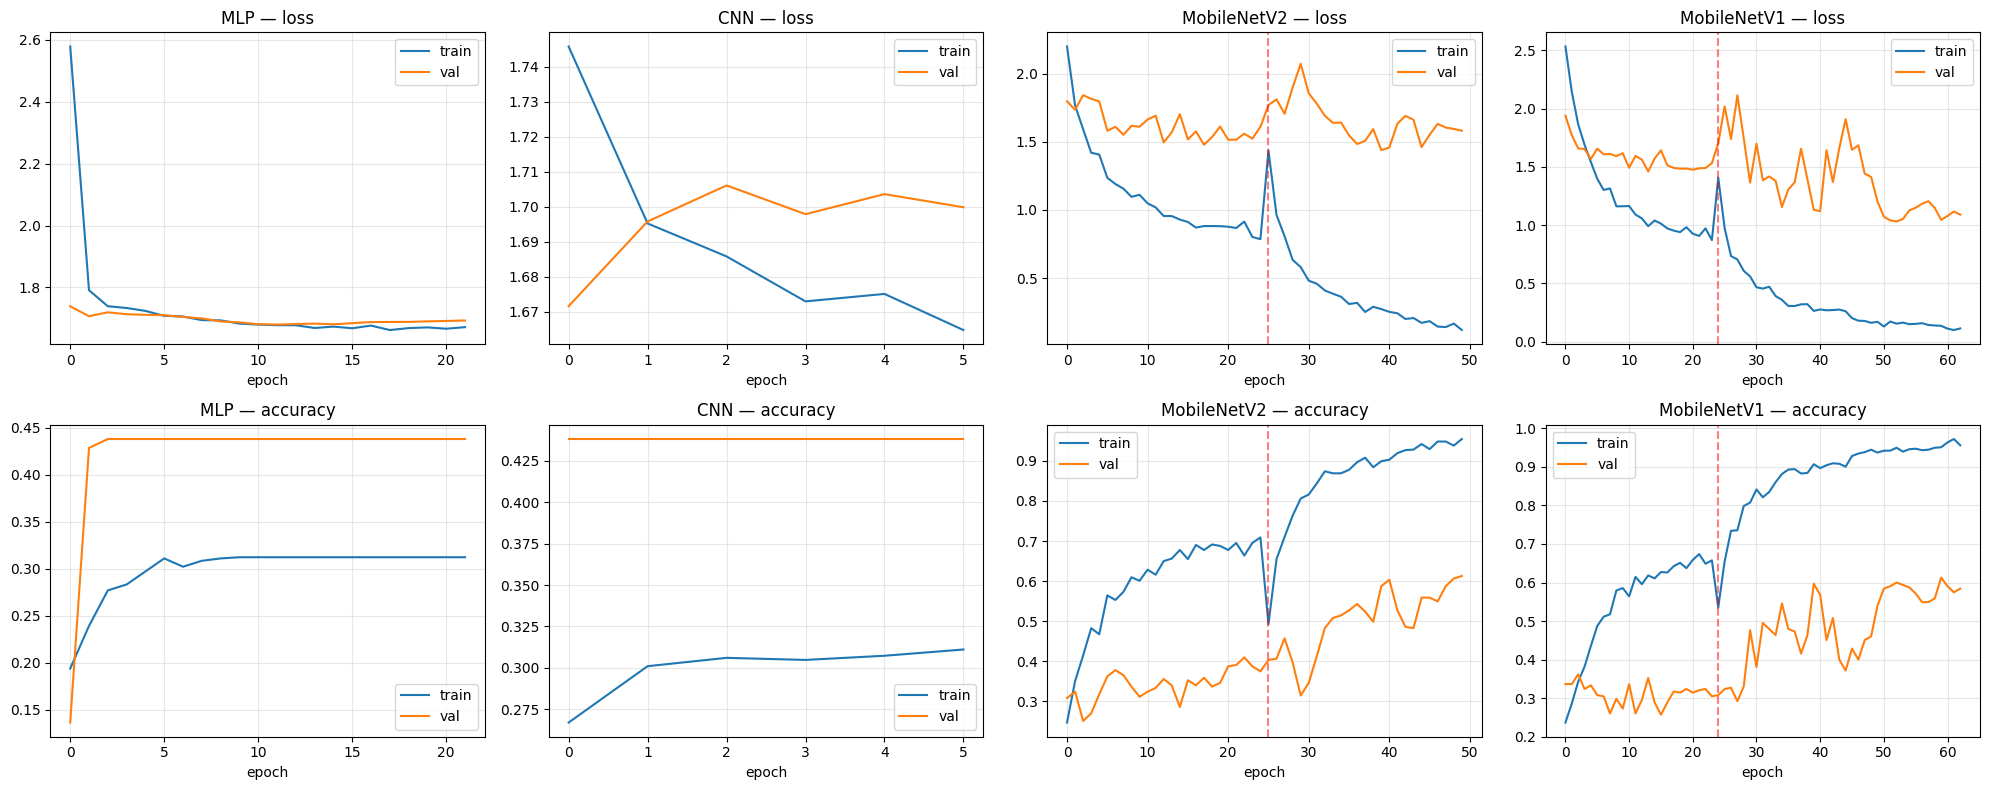

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
panels = [
    ("MLP",         hist_mlp.history,  False),
    ("CNN",         hist_cnn.history,  False),
    ("MobileNetV2", hist_mbv2,         True),
    ("MobileNetV1", hist_mbv1,         True),
]
boundary_v2 = len(hist_mbv2_s1.history["loss"])
boundary_v1 = len(hist_mbv1_s1.history["loss"])
for col, (name, h, has_boundary) in enumerate(panels):
    axes[0, col].plot(h["loss"], label="train")
    axes[0, col].plot(h["val_loss"], label="val")
    axes[0, col].set_title(f"{name} — loss")
    axes[0, col].set_xlabel("epoch")
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)
    axes[1, col].plot(h["accuracy"], label="train")
    axes[1, col].plot(h["val_accuracy"], label="val")
    axes[1, col].set_title(f"{name} — accuracy")
    axes[1, col].set_xlabel("epoch")
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)
    if has_boundary:
        boundary = boundary_v2 if name == "MobileNetV2" else boundary_v1
        axes[0, col].axvline(boundary, linestyle="--", alpha=0.5, color="red")
        axes[1, col].axvline(boundary, linestyle="--", alpha=0.5, color="red")
plt.tight_layout()
plt.show()

In [11]:
def build_mbv2_variant(backbone_fn, head="small", aug_color=False):
    tf.keras.backend.clear_session(); tf.random.set_seed(42)
    backbone = backbone_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    backbone.trainable = False
    inputs = tf.keras.Input((224, 224, 3))
    x = inputs
    if aug_color:
        x = tf.keras.layers.RandomBrightness(0.2)(x)
        x = tf.keras.layers.RandomContrast(0.2)(x)
    x = tf.keras.layers.Rescaling(1/127.5, offset=-1)(x)
    x = backbone(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    if head == "large":
        x = tf.keras.layers.Dense(64, activation="relu")(x)
        x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(6, activation="softmax")(x)
    return tf.keras.Model(inputs, out), backbone

def train_two_step(model, backbone, train_ds, val_ds):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=25,
                   callbacks=make_callbacks(), verbose=0)
    backbone.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=100,
                   initial_epoch=len(h1.history["loss"]),
                   callbacks=make_callbacks(patience=15), verbose=0)
    return max(h2.history["val_accuracy"])

# V1 is now a primary model in cell 15 rather than a sweep variant. The sweep
# evaluates the two remaining §12.2 candidates (larger head, heavier color
# augmentation) against the MobileNetV2 baseline.
variants = {
    "MobileNetV2 + larger head": (tf.keras.applications.MobileNetV2, "large", False),
    "MobileNetV2 + color aug":   (tf.keras.applications.MobileNetV2, "small", True),
}

sweep_results = {
    "baseline (MobileNetV2)": max(hist_mbv2["val_accuracy"]),
    "reference (MobileNetV1)": max(hist_mbv1["val_accuracy"]),
}
for name, (bb, head, aug) in variants.items():
    print(f"\n--- {name} ---")
    m, bb_ref = build_mbv2_variant(bb, head=head, aug_color=aug)
    sweep_results[name] = train_two_step(m, bb_ref, train_ds, val_ds)

print("\nval accuracy sweep:")
for name, va in sweep_results.items():
    print(f"  {name:<35} {va:.3f}")


--- MobileNetV2 + larger head ---

--- MobileNetV2 + color aug ---

val accuracy sweep:
  baseline (MobileNetV2)              0.613
  reference (MobileNetV1)             0.613
  MobileNetV2 + larger head           0.502
  MobileNetV2 + color aug             0.521


## Classification Evaluation

Each model's test-set predictions are evaluated with metrics appropriate for an ordinal classification problem:

- **Accuracy** — exact-class match
- **±1 accuracy** — counts as correct if the prediction is within one class of ground truth, motivated by the observation that even human experts disagree by ±1 on this task (Lue et al. 2014)
- **F1 macro** — average of per-class F1 scores; weights rare classes (0, 5) equally with the dominant class (3)
- **Confusion matrix** — diagnostic per-class structure, normalized by row
- **Accuracy stratified by annotation difficulty** — easy / moderate / difficult subsets of the test set, following the paired paper
- **Confidence vs. accuracy correlation** — for both MobileNetV2 and MobileNetV1, since the from-scratch models are degenerate constant-predictors; the paper reports R² ≈ 0.90 on Dataset 1

A majority-class baseline (predict the train-set mode on every test instance) is included alongside the four models as a "thing to beat" — any model below this baseline is not learning anything useful from the input.

Model            Accuracy     ±1 acc   F1 macro
----------------------------------------------
Majority            0.223      0.573      0.061
MLP                 0.223      0.573      0.061
CNN                 0.223      0.573      0.061
MobileNetV2         0.433      0.754      0.383
MobileNetV1         0.496      0.791      0.449


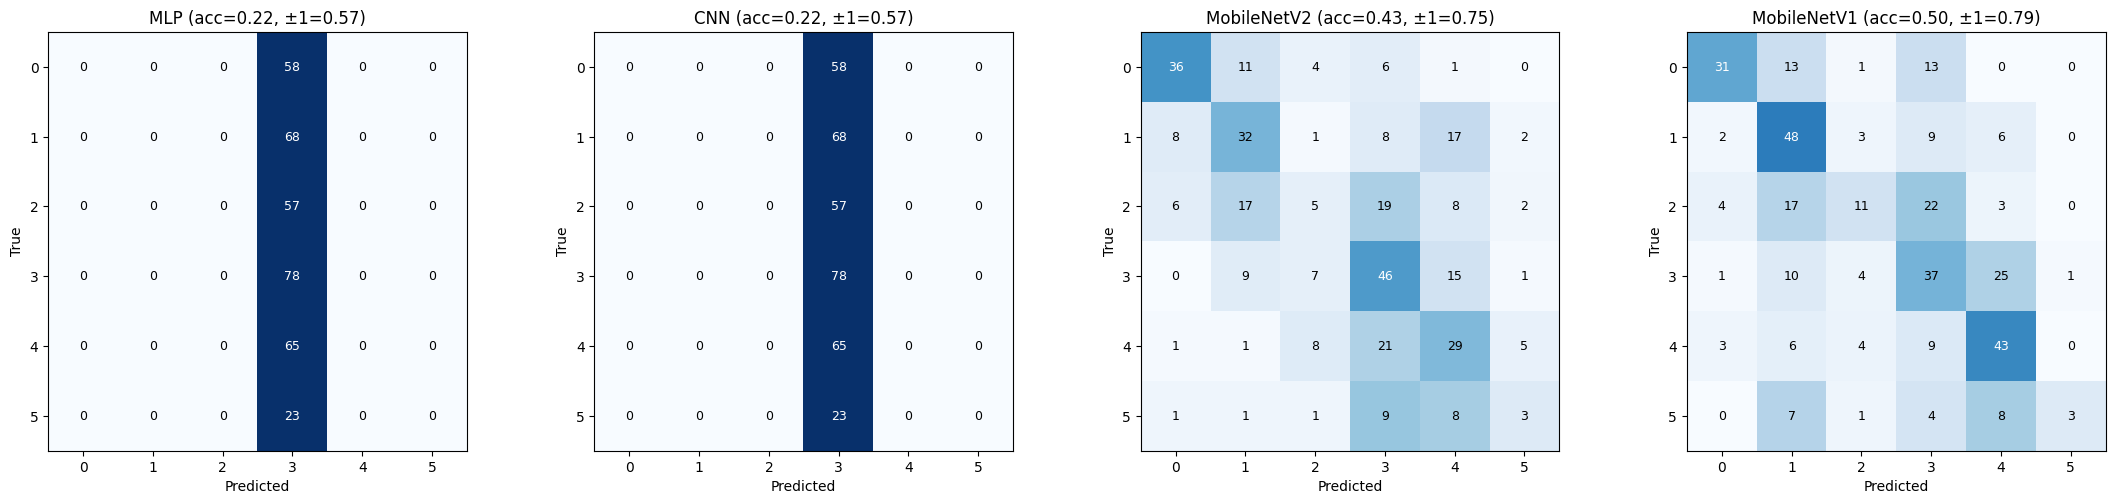


Accuracy stratified by annotation effort:
Model                         Easy            Moderate           Difficult
--------------------------------------------------------------------------
MLP                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
CNN                   0.052 (n=58)       0.262 (n=248)        0.233 (n=43)
MobileNetV2           0.466 (n=58)       0.427 (n=248)        0.419 (n=43)
MobileNetV1           0.569 (n=58)       0.456 (n=248)        0.628 (n=43)


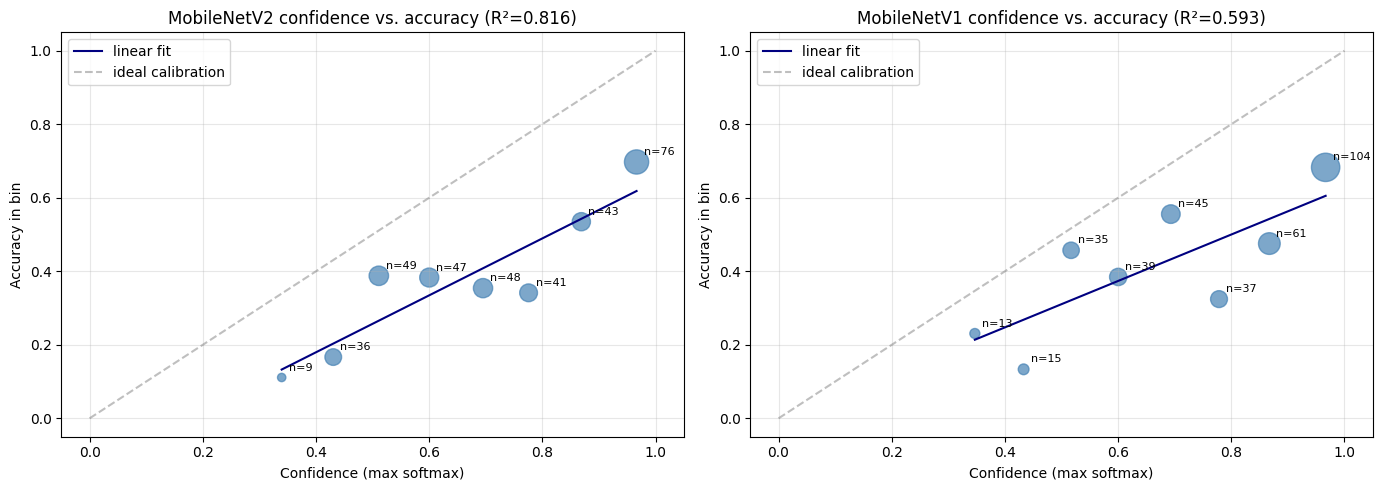

In [12]:
models = {"MLP": mlp, "CNN": cnn, "MobileNetV2": mbv2, "MobileNetV1": mbv1}
results = {}
for name, model in models.items():
    proba = model.predict(test_ds, verbose=0)
    pred = np.argmax(proba, axis=1)
    results[name] = {
        "proba":    proba,
        "pred":     pred,
        "acc":      accuracy_score(y_test, pred),
        "acc_pm1":  np.mean(np.abs(y_test - pred) <= 1),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
    }

# Majority-class baseline: predict the train-set mode on every test instance
majority_class = pd.Series(y_train).mode().iloc[0]
y_pred_majority = np.full(len(y_test), majority_class)
results["Majority"] = {
    "pred":     y_pred_majority,
    "acc":      accuracy_score(y_test, y_pred_majority),
    "acc_pm1":  np.mean(np.abs(y_test - y_pred_majority) <= 1),
    "f1_macro": f1_score(y_test, y_pred_majority, average="macro", zero_division=0),
}

# Headline metrics
print(f"{'Model':<14} {'Accuracy':>10} {'±1 acc':>10} {'F1 macro':>10}")
print("-" * 46)
for name in ["Majority", "MLP", "CNN", "MobileNetV2", "MobileNetV1"]:
    r = results[name]
    print(f"{name:<14} {r['acc']:>10.3f} {r['acc_pm1']:>10.3f} {r['f1_macro']:>10.3f}")

# Confusion matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, name in zip(axes, ["MLP", "CNN", "MobileNetV2", "MobileNetV1"]):
    r = results[name]
    cm = confusion_matrix(y_test, r["pred"], labels=range(6))
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{name} (acc={r['acc']:.2f}, ±1={r['acc_pm1']:.2f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    for i in range(6):
        for j in range(6):
            color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=9)
plt.tight_layout()
plt.show()

# Accuracy stratified by annotation difficulty
test_effort = df.loc[test_idx, "effort"].to_numpy()
print("\nAccuracy stratified by annotation effort:")
header = f"{'Model':<14}" + "".join(f"{l:>20}" for l in ["Easy", "Moderate", "Difficult"])
print(header)
print("-" * len(header))
for name in ["MLP", "CNN", "MobileNetV2", "MobileNetV1"]:
    cells = []
    for eff in [0, 1, 2]:
        m = test_effort == eff
        cells.append(f"{accuracy_score(y_test[m], results[name]['pred'][m]):.3f} (n={m.sum()})")
    print(f"{name:<14}" + "".join(f"{c:>20}" for c in cells))

# MobileNet confidence vs accuracy (paper §3.2 reports R²=0.896 on Dataset 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["MobileNetV2", "MobileNetV1"]):
    proba = results[name]["proba"]
    pred  = results[name]["pred"]
    confidence = proba.max(axis=1)
    correct    = (pred == y_test).astype(float)
    bins = np.linspace(confidence.min(), 1.0, 9)
    bin_acc, bin_n, bin_centers = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (confidence >= lo) & (confidence < hi if hi < 1.0 else confidence <= hi)
        if m.sum() > 0:
            bin_acc.append(correct[m].mean())
            bin_n.append(m.sum())
            bin_centers.append(confidence[m].mean())
    bin_acc, bin_n, bin_centers = map(np.array, (bin_acc, bin_n, bin_centers))
    ax.scatter(bin_centers, bin_acc, s=bin_n * 4, alpha=0.7, color="steelblue")
    for x, y, n in zip(bin_centers, bin_acc, bin_n):
        ax.annotate(f"n={n}", (x, y), fontsize=8, xytext=(5, 5), textcoords="offset points")
    if len(bin_centers) >= 2:
        slope, intercept = np.polyfit(bin_centers, bin_acc, 1)
        xs = np.linspace(bin_centers.min(), bin_centers.max(), 50)
        ax.plot(xs, slope * xs + intercept, color="navy", label="linear fit")
        r2 = np.corrcoef(bin_centers, bin_acc)[0, 1] ** 2
    else:
        r2 = float("nan")
    ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="ideal calibration")
    ax.set_xlabel("Confidence (max softmax)")
    ax.set_ylabel("Accuracy in bin")
    ax.set_title(f"{name} confidence vs. accuracy (R²={r2:.3f})")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Statistical Analyses

Three analyses motivated by Cheng et al. (2021): a one-tailed z-test on accuracy across annotation-difficulty strata (paper §3.2), a building-attribute correlation analysis on damage class vs. number of stories and bounding-box area (paper §4.2 / Table 11), and a bounding-box-area-filtered evaluation testing the §12.3 hypothesis that small upscaled patches drive a measurable share of misclassifications. Analyses are run on MobileNetV1 since it is the paper-faithful model and has the more diagnostic confusion-matrix structure.

In [13]:
# One-tailed z-test (95%) on accuracy across annotation difficulty.
# Replicates Cheng et al. (2021) §3.2: easy samples should be classified more
# accurately than moderate or difficult samples.
from statsmodels.stats.proportion import proportions_ztest

target_model = "MobileNetV1"
test_effort  = df.loc[test_idx, "effort"].to_numpy()
pred         = results[target_model]["pred"]
correct      = (pred == y_test).astype(int)

print(f"Annotation-difficulty z-tests on {target_model} (one-tailed, 95% confidence)\n")
strata = {0: "easy", 1: "moderate", 2: "difficult"}
counts, ns, accs = {}, {}, {}
for k, label in strata.items():
    m = test_effort == k
    counts[k], ns[k] = correct[m].sum(), m.sum()
    accs[k] = counts[k] / max(ns[k], 1)
    print(f"  {label:9s}: n={ns[k]:3d}, correct={counts[k]:3d}, acc={accs[k]:.3f}")

print(f"\n{'comparison':<24} {'z':>8} {'p (one-tail)':>14} {'reject H0?':>12}")
print("-" * 60)
for a, b in [(0, 1), (0, 2), (1, 2)]:
    # H1: stratum a has higher accuracy than stratum b
    z, p_two = proportions_ztest(
        count=[counts[a], counts[b]],
        nobs=[ns[a], ns[b]],
        alternative="larger",
    )
    sig = "yes" if p_two < 0.05 else "no"
    print(f"  {strata[a]:8s} > {strata[b]:9s} {z:>8.3f} {p_two:>14.4f} {sig:>12}")

Annotation-difficulty z-tests on MobileNetV1 (one-tailed, 95% confidence)

  easy     : n= 58, correct= 33, acc=0.569
  moderate : n=248, correct=113, acc=0.456
  difficult: n= 43, correct= 27, acc=0.628

comparison                      z   p (one-tail)   reject H0?
------------------------------------------------------------
  easy     > moderate     1.556         0.0599           no
  easy     > difficult   -0.596         0.7246           no
  moderate > difficult   -2.087         0.9816           no


In [14]:
# Building-attribute correlation: damage class vs. number of stories.
# Replicates the structure of Cheng et al. (2021) Table 11 / §4.2.
# Two-tailed z-test on mean damage between one-story and 2+-story buildings.
from statsmodels.stats.weightstats import ztest

# Use building-level (one row per unique building) modal damage and modal stories
test_buildings = (df.loc[test_idx]
                    .groupby("building_id")
                    .agg(damage=("damage", lambda s: s.mode().iloc[0]),
                         stories=("stories", lambda s: s.mode().iloc[0]))
                    .reset_index())

print(f"Building-attribute analysis on test set ({len(test_buildings)} unique buildings)\n")

# Stories distribution
print("Stories distribution:")
print(test_buildings["stories"].value_counts().sort_index().to_string())

# Mean damage by stories
print("\nMean damage by number of stories:")
for s, grp in test_buildings.groupby("stories"):
    print(f"  {s} stories: n={len(grp):3d}, mean damage={grp['damage'].mean():.3f}")

# z-test: 1-story vs ≥2-story
one_story = test_buildings.loc[test_buildings["stories"] == 1, "damage"].to_numpy()
multi_story = test_buildings.loc[test_buildings["stories"] >= 2, "damage"].to_numpy()
if len(one_story) >= 5 and len(multi_story) >= 5:
    z, p = ztest(one_story, multi_story, alternative="two-sided")
    print(f"\nTwo-tailed z-test (1-story vs. 2+-story):")
    print(f"  z = {z:.3f}, p = {p:.4f}")
    print(f"  reject H0 (no difference)? {'yes' if p < 0.05 else 'no'}")
else:
    print("\nInsufficient samples per stratum for z-test.")

Building-attribute analysis on test set (30 unique buildings)

Stories distribution:
stories
1    28
2     2

Mean damage by number of stories:
  1 stories: n= 28, mean damage=2.714
  2 stories: n=  2, mean damage=2.000

Insufficient samples per stratum for z-test.


## Example Error Grid

For each MobileNet variant, a 6×6 grid of test patches arranged by (true class, predicted class). The diagonal shows correctly-classified examples; off-diagonal cells visualize specific error patterns from the confusion matrices above. Cells marked with "—" indicate no test sample fell in that (true, pred) combination. Cell counts (`n=...`) report how many test samples landed there; the displayed image is the first such sample in test-set order.

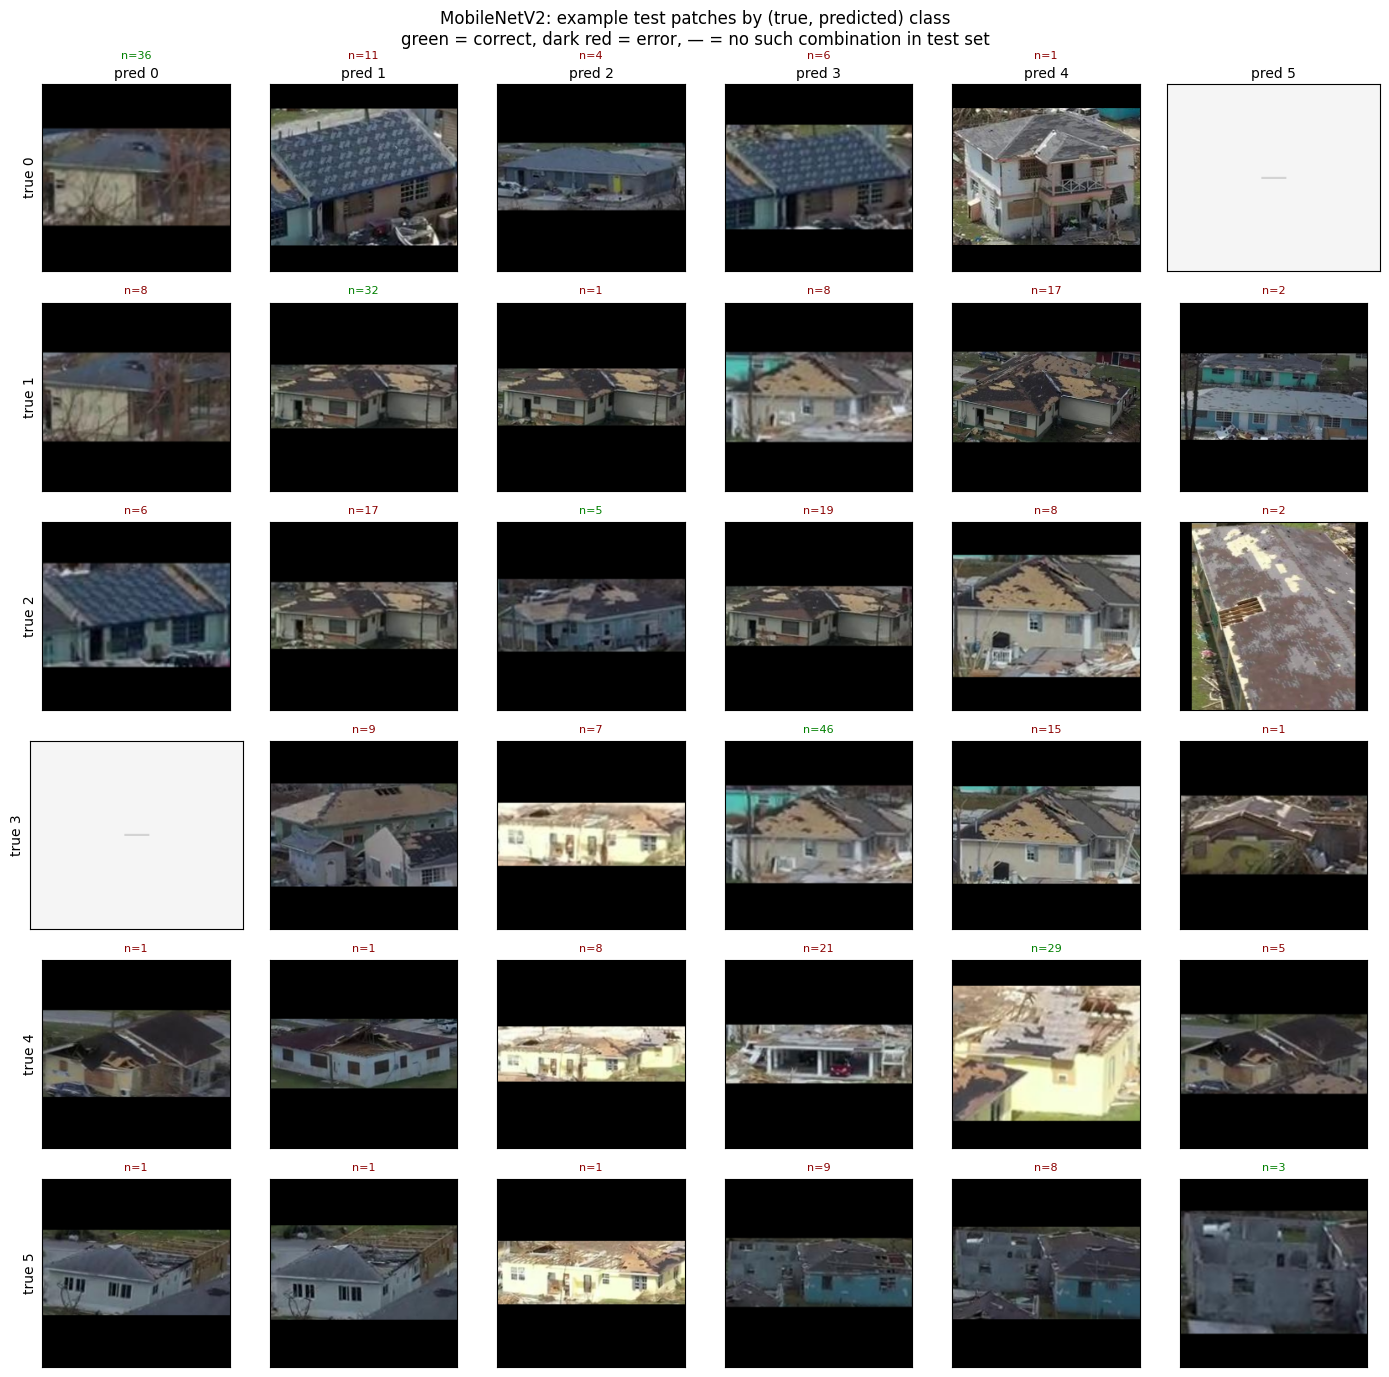

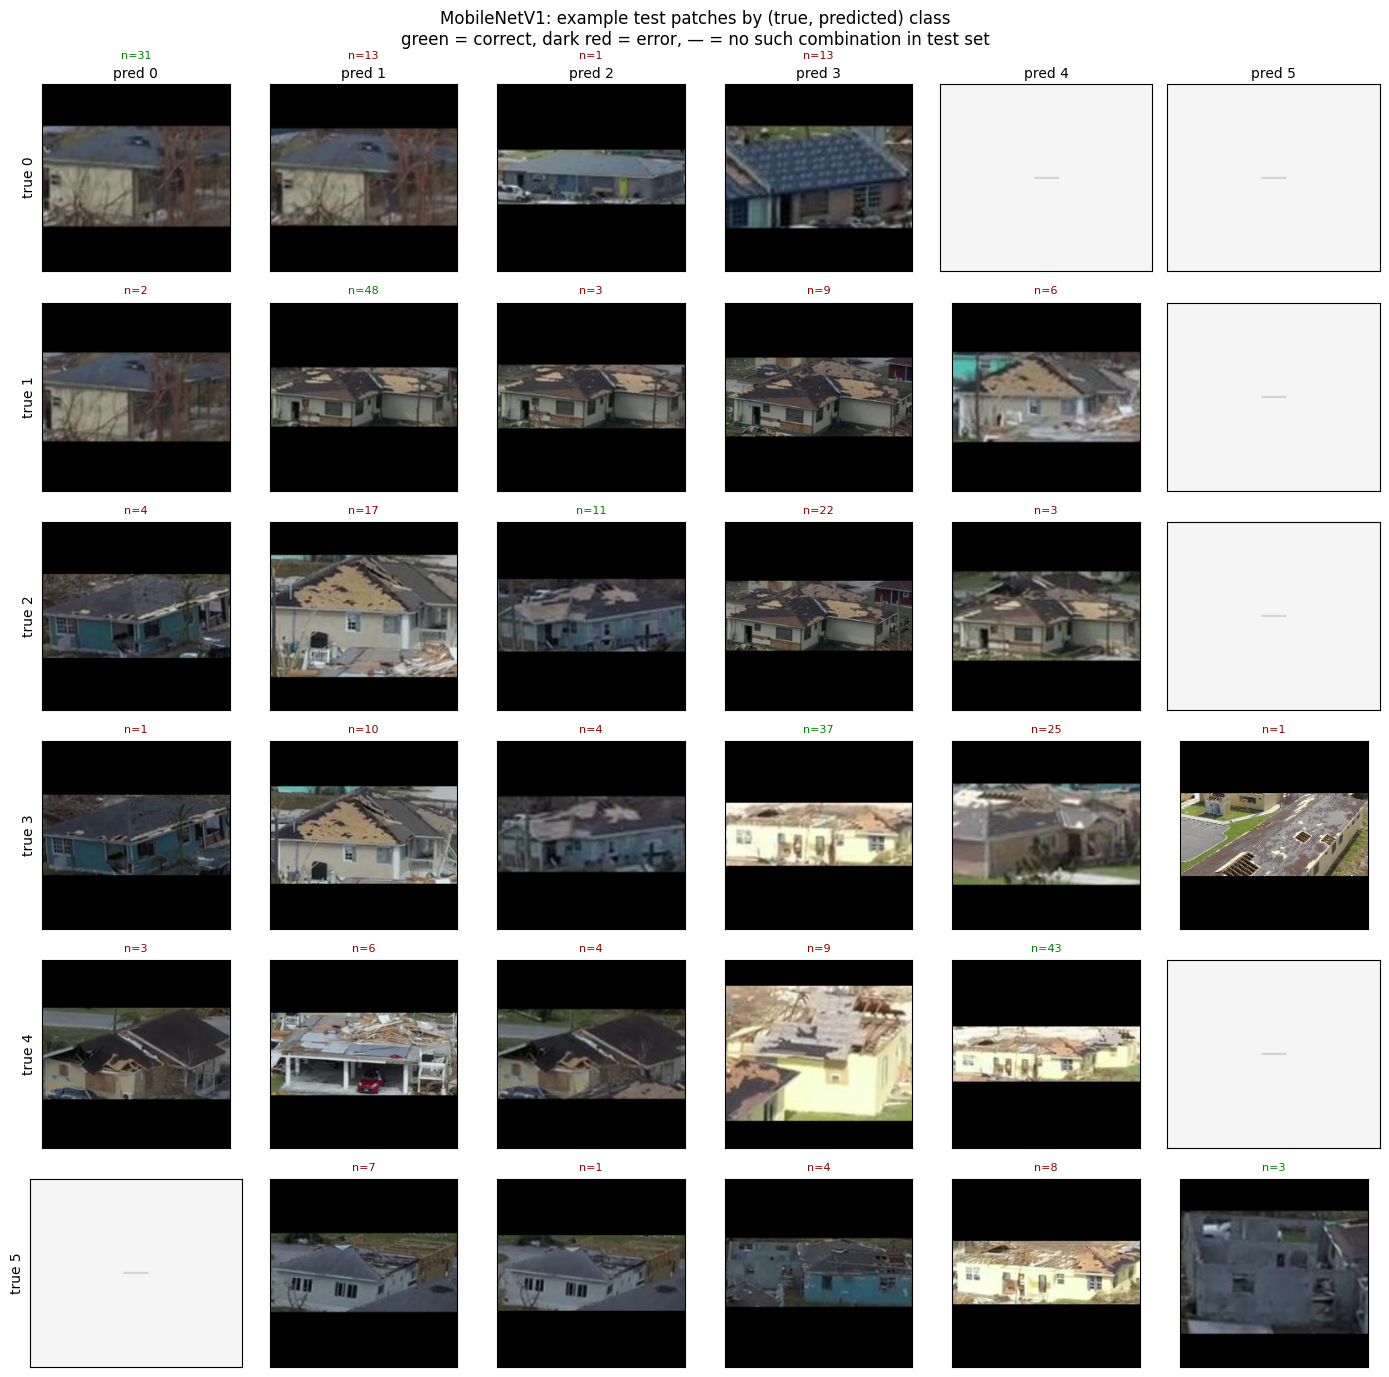

In [15]:
# Example error grid: one patch per (true class, predicted class) cell.
# Two figures, one per MobileNet variant. Diagonal = correct predictions;
# off-diagonal = errors. Empty cells where no test sample falls in that combination.
def plot_error_grid(model_name, results, y_test, test_idx, df, patches):
    pred = results[model_name]["pred"]
    fig, axes = plt.subplots(6, 6, figsize=(14, 14))
    for true_cls in range(6):
        for pred_cls in range(6):
            ax = axes[true_cls, pred_cls]
            mask = (y_test == true_cls) & (pred == pred_cls)
            local_indices = np.where(mask)[0]
            if len(local_indices) > 0:
                # Pick a deterministic example: first matching test sample
                df_idx = test_idx[local_indices[0]]
                ax.imshow(patches[df_idx])
                ax.set_title(f"n={len(local_indices)}", fontsize=8,
                             color=("green" if true_cls == pred_cls else "darkred"))
            else:
                ax.set_facecolor("#f5f5f5")
                ax.text(0.5, 0.5, "—", ha="center", va="center",
                        transform=ax.transAxes, color="lightgray", fontsize=20)
            ax.set_xticks([]); ax.set_yticks([])
            if pred_cls == 0:
                ax.set_ylabel(f"true {true_cls}", fontsize=10)
            if true_cls == 0:
                ax.set_xlabel(f"pred {pred_cls}", fontsize=10)
                ax.xaxis.set_label_position("top")
    plt.suptitle(f"{model_name}: example test patches by (true, predicted) class\n"
                 f"green = correct, dark red = error, — = no such combination in test set",
                 fontsize=12)
    plt.tight_layout()
    plt.show()

for name in ["MobileNetV2", "MobileNetV1"]:
    plot_error_grid(name, results, y_test, test_idx, df, patches)